# notebook 1, exploring the wfp food price data

what this notebook does: loads the raw price records, cleans them, and looks at
the basic shape of the data. how many regions, which commodities, how prices
move over the years and seasons.

about the dataset. the numbers come from the world food programme (wfp), which
tracks food prices in markets across countries where food insecurity is a concern.
for cameroon, the file covers 2005 to 2026 and has roughly 75,000 raw price
observations in cfa francs (xaf), the local currency.

one thing to notice. cameroon has 10 regions but the dataset only contains 9. the
missing one is sud (south). wfp focuses its monitoring on regions affected by
crises, the far north (boko haram), the northwest and southwest (the anglophone
conflict), and the east (refugees from the central african republic). the south
region is relatively stable and food secure so it isn't part of wfp's regular
monitoring. that's a normal limitation of humanitarian datasets, they go where
the need is.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('wfp_food_prices_cameroon.csv')
df['date'] = pd.to_datetime(df['date'])

# keep only retail prices and remove bad rows
df = df[df['pricetype'] == 'Retail']
df = df[df['price'] > 0].copy()

# add year and month columns
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month

print('rows after cleaning:', df.shape[0])
df.head()

rows after cleaning: 55660


,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice,year,month
0,2005-01-15,Centre,Mfoundi,Yaoundé-Mfoundi,2613,3.86,11.52,cereals and tubers,Maize (white),67,KG,actual,Retail,XAF,147.78,0.30,2005,1
1,2005-01-15,Centre,Mfoundi,Yaoundé-Mfoundi,2613,3.86,11.52,cereals and tubers,Maize (yellow),136,KG,actual,Retail,XAF,147.78,0.30,2005,1
2,2005-01-15,Littoral,Wouri,Douala-Congo,2579,4.04,9.70,cereals and tubers,Maize (white),67,KG,actual,Retail,XAF,183.64,0.37,2005,1
3,2005-01-15,Littoral,Wouri,Douala-Congo,2579,4.04,9.70,cereals and tubers,Maize (yellow),136,KG,actual,Retail,XAF,183.64,0.37,2005,1
4,2005-01-15,Nord,Bénoué,Garoua,1593,9.30,13.40,cereals and tubers,Maize (white),67,KG,actual,Retail,XAF,127.53,0.25,2005,1


In [2]:
# quick data quality check before we start
raw = pd.read_csv('wfp_food_prices_cameroon.csv')
print(f'raw rows         : {len(raw):,}')
print(f'missing values   : {raw.isna().sum().sum()}')
print(f'duplicate rows   : {raw.duplicated().sum()}')
print(f'price types      : {raw["pricetype"].value_counts().to_dict()}')
print(f'currencies       : {list(raw["currency"].unique())}')


raw rows         : 74,955
missing values   : 0


duplicate rows   : 0
price types      : {'Retail': 55660, 'Wholesale': 19295}
currencies       : ['XAF']


In [3]:
# quick summary of key columns
print('date range:', df['date'].min().date(), 'to', df['date'].max().date())
print('regions:', df['admin1'].nunique())
print('commodities:', df['commodity'].nunique())
print('markets:', df['market'].nunique())
print()
df[['price']].describe().round(1)

date range: 2005-01-15 to 2026-03-15
regions: 9
commodities: 51
markets: 76



,price
count,55660.0
mean,947.5
std,1092.8
min,3.0
25%,339.0
50%,600.0
75%,1175.0
max,52000.0


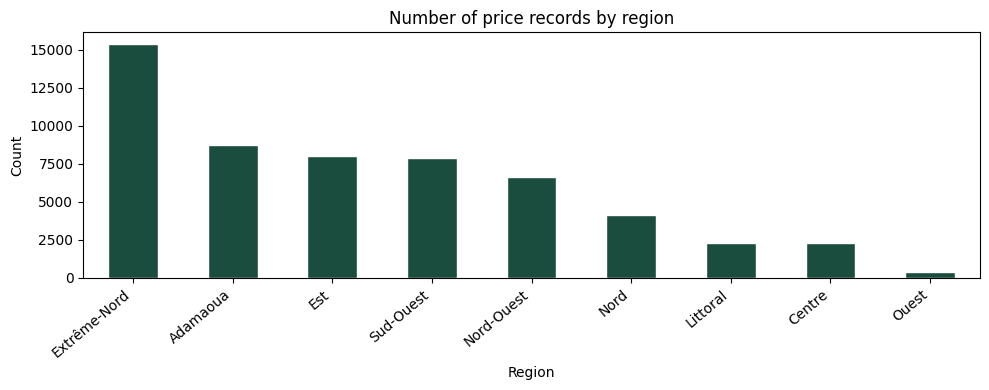

In [4]:
# records per region
df['admin1'].value_counts().plot(kind='bar', color='#1B4D3E', edgecolor='white', figsize=(10,4))
plt.title('Number of price records by region')
plt.xlabel('Region'); plt.ylabel('Count')
plt.xticks(rotation=40, ha='right'); plt.tight_layout(); plt.show()

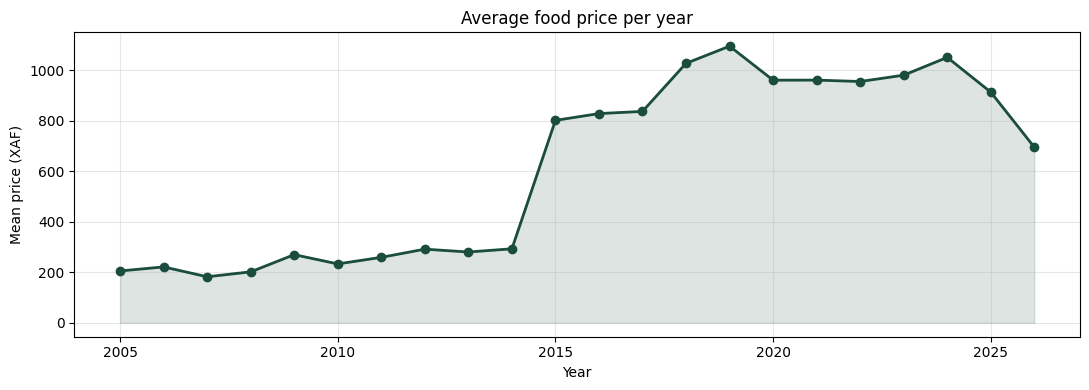

In [5]:
# average price per year — shows the overall trend
yearly = df.groupby('year')['price'].mean()
yearly.plot(marker='o', color='#1B4D3E', linewidth=2, figsize=(11,4))
plt.fill_between(yearly.index, yearly.values, alpha=0.15, color='#1B4D3E')
plt.title('Average food price per year')
plt.xlabel('Year'); plt.ylabel('Mean price (XAF)')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

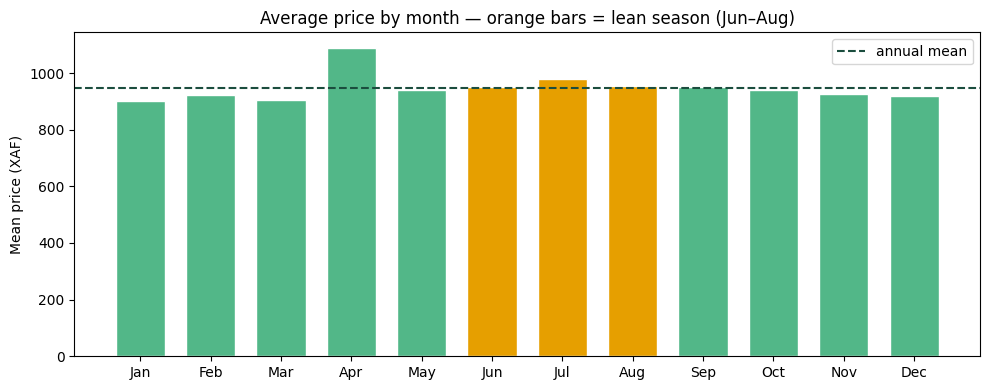

In [6]:
# average price by calendar month
month_avg = df.groupby('month')['price'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
colors = ['#E69F00' if m in [6,7,8] else '#52B788' for m in range(1,13)]
plt.figure(figsize=(10,4))
plt.bar(range(1,13), month_avg.values, color=colors, edgecolor='white', width=0.7)
plt.xticks(range(1,13), month_names)
plt.axhline(month_avg.mean(), color='#1B4D3E', linestyle='--', linewidth=1.5, label='annual mean')
plt.title('Average price by month — orange bars = lean season (Jun–Aug)')
plt.ylabel('Mean price (XAF)'); plt.legend(); plt.tight_layout(); plt.show()

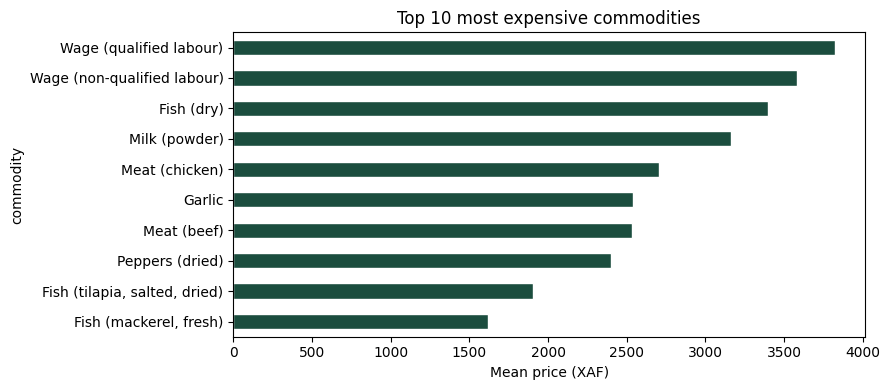

In [7]:
# top 10 most expensive commodities on average
top10 = df.groupby('commodity')['price'].mean().sort_values(ascending=False).head(10)
top10.sort_values().plot(kind='barh', color='#1B4D3E', edgecolor='white', figsize=(9,4))
plt.title('Top 10 most expensive commodities')
plt.xlabel('Mean price (XAF)'); plt.tight_layout(); plt.show()

In [8]:
# save cleaned file for the other notebooks
df.to_csv('wfp_food_prices_clean.csv', index=False)
print('saved wfp_food_prices_clean.csv with', len(df), 'rows')

saved wfp_food_prices_clean.csv with 55660 rows


### what we learned from exploration

1. the data is clean. no missing values, no duplicates. cleaning only meant
   filtering to retail prices and removing zero price rows.
2. coverage is uneven. the far north has the most price records because wfp
   monitors it most closely, the west has the fewest.
3. prices rise sharply after 2020, reflecting global food inflation and the
   aftermath of covid.
4. june to august is the lean season. these are the months between harvests when
   food stocks are lowest and prices climb above the annual average.
5. imported and processed items dominate the top of the price list (oils, meat,
   fish), while local staples (maize, cassava) stay cheaper.

the cleaned file is saved as wfp_food_prices_clean.csv and is used by every
other notebook in this project.
